# Divvy Bike-Sharing EDA — Chicago 2017

All analysis is built on the demand table produced by `src/data/build_clean_df.py`.

Sections:
1. Data loading (`build_divvy_datasets`)
2. Dataset overview
3. Temporal patterns (hour, day-of-week, month)
4. Station-level analysis
5. Chicago maps (heatmaps, net demand, animated)
6. Weather impact
7. Demand imbalance

In [1]:
import sys
from pathlib import Path

import folium
import folium.plugins as fplugins
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path("../")
sys.path.insert(0, str(ROOT))

from src.data.build_clean_df import build_divvy_datasets, WeatherConfig

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "results" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

DOW_LABELS   = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
CHICAGO = [41.8781, -87.6298]

/Users/martynaharasym/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. Data Loading

If the processed CSV already exists we load it directly (fast path).  
Otherwise we call `build_divvy_datasets()` which cleans raw trips, builds the station × hour grid, fetches weather, and saves the result.

In [2]:
DEMAND_CSV = PROCESSED / "divvy_hourly_demand_weather.csv"

if DEMAND_CSV.exists():
    print("Loading pre-built demand table …")
    demand = pd.read_csv(DEMAND_CSV, parse_dates=["hour"])
else:
    print("Building demand table from raw files …")
    demand = build_divvy_datasets(
        trip_paths=[
            RAW / "Divvy_Trips_2017_Q1.csv",
            RAW / "Divvy_Trips_2017_Q2.csv",
            RAW / "Divvy_Trips_2017_Q3.csv",
            RAW / "Divvy_Trips_2017_Q4.csv",
        ],
        stations_path=RAW / "Divvy_Stations_2017_Q3Q4 (2).csv",
        save_demand_to=DEMAND_CSV,
    )

# Attach station metadata (name, lat/lon, capacity) for maps and labels
stations = pd.read_csv(RAW / "Divvy_Stations_2017_Q3Q4 (2).csv")
stations["id"] = pd.to_numeric(stations["id"], errors="coerce")
demand = demand.merge(
    stations[["id", "name", "latitude", "longitude", "dpcapacity"]].rename(columns={"id": "station_id"}),
    on="station_id", how="left",
)

# Derived time columns used throughout
demand["hour_of_day"] = demand["hour"].dt.hour
demand["day_of_week"] = demand["hour"].dt.dayofweek   # 0 = Mon
demand["month"]       = demand["hour"].dt.month
demand["is_weekend"]  = demand["day_of_week"].isin([5, 6])
demand["date"]        = demand["hour"].dt.date

print(f"\nDemand table: {len(demand):,} rows")
print(f"Stations: {demand['station_id'].nunique()} | Hours: {demand['hour'].nunique()}")
print(f"Period: {demand['hour'].min().date()} → {demand['hour'].max().date()}")
demand.head(3)

Loading pre-built demand table …



Demand table: 5,125,185 rows
Stations: 585 | Hours: 8761
Period: 2017-01-01 → 2018-01-01


,station_id,hour,departures,arrivals,net_demand,temp,tmin,tmax,rhum,prcp,...,pres,name,latitude,longitude,dpcapacity,hour_of_day,day_of_week,month,is_weekend,date
0,66,2017-01-01 00:00:00,0,0,0,-1.1,-6.2,4.9,65,0.0,...,1020.4,Clinton St & Lake St,41.885637,-87.641823,23,0,6,1,True,2017-01-01
1,66,2017-01-01 01:00:00,0,0,0,-1.1,-6.2,4.9,65,0.0,...,1020.4,Clinton St & Lake St,41.885637,-87.641823,23,1,6,1,True,2017-01-01
2,66,2017-01-01 02:00:00,0,0,0,-1.1,-6.2,4.9,65,0.0,...,1020.4,Clinton St & Lake St,41.885637,-87.641823,23,2,6,1,True,2017-01-01


## 2. Dataset Overview

In [3]:
total_dep = demand["departures"].sum()
total_arr = demand["arrivals"].sum()
n_stations = demand["station_id"].nunique()

print(f"Total departures : {total_dep:,}")
print(f"Total arrivals   : {total_arr:,}")
print(f"Active stations  : {n_stations}")
print(f"\nPer station-hour — departures:")
print(demand["departures"].describe().to_string())

Total departures : 3,829,014
Total arrivals   : 3,829,014
Active stations  : 585

Per station-hour — departures:
count    5.125185e+06
mean     7.470977e-01
std      2.568557e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      1.520000e+02


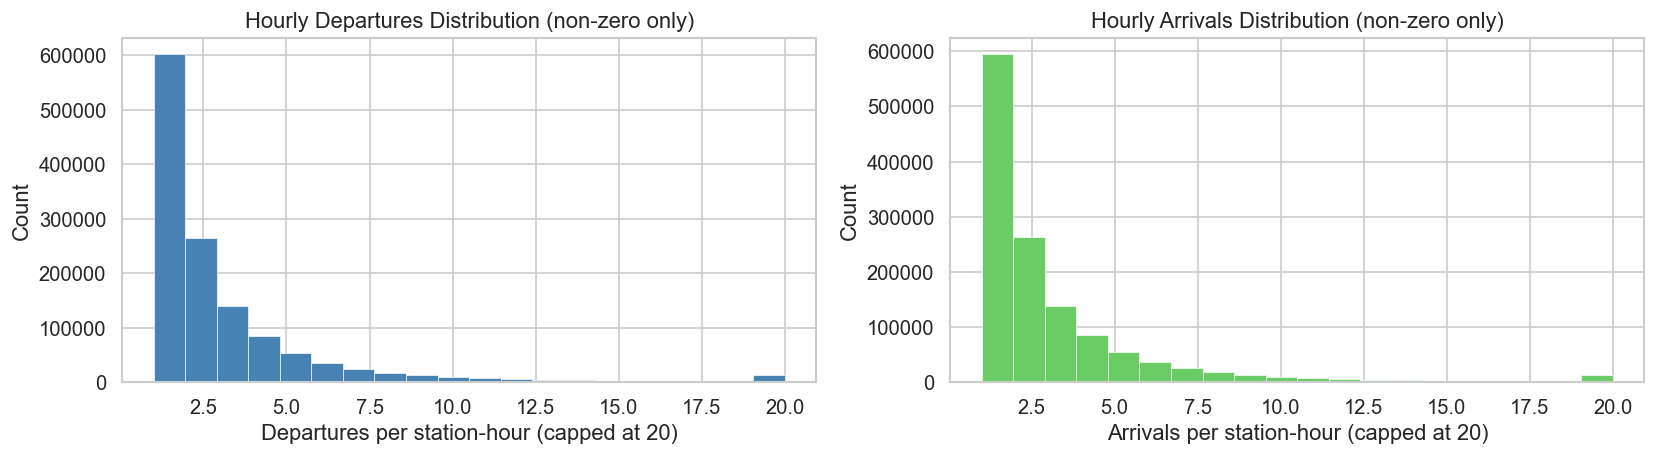

In [4]:
# Distribution of non-zero hourly departures and arrivals
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, color, label in [
    (axes[0], "departures", "steelblue", "Departures"),
    (axes[1], "arrivals",   "#6ACC65",   "Arrivals"),
]:
    vals = demand.loc[demand[col] > 0, col].clip(upper=20)
    ax.hist(vals, bins=20, color=color, edgecolor="white", linewidth=0.4)
    ax.set_xlabel(f"{label} per station-hour (capped at 20)")
    ax.set_ylabel("Count")
    ax.set_title(f"Hourly {label} Distribution (non-zero only)")

plt.tight_layout()
plt.show()

In [5]:
# Fraction of station-hours with zero activity
zero_dep = (demand["departures"] == 0).mean()
zero_arr = (demand["arrivals"]   == 0).mean()
print(f"Station-hours with 0 departures : {zero_dep:.1%}")
print(f"Station-hours with 0 arrivals   : {zero_arr:.1%}")
print(f"Missing weather (temp NaN)      : {demand['temp'].isna().mean():.1%}")

Station-hours with 0 departures : 74.7%
Station-hours with 0 arrivals   : 74.9%
Missing weather (temp NaN)      : 0.0%


## 3. Temporal Patterns

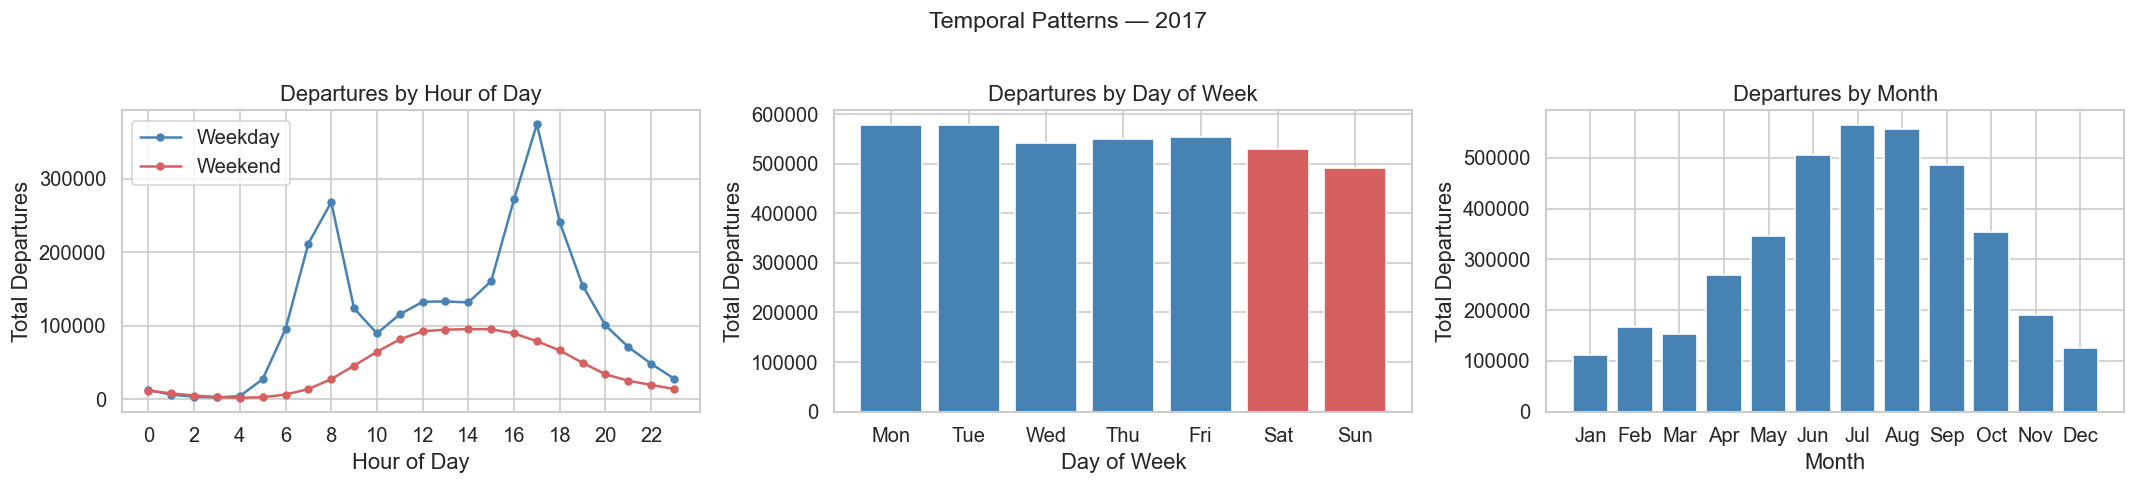

In [6]:
# Aggregate total departures per time slice (sum across all stations)
hourly_total  = demand.groupby(["hour_of_day", "is_weekend"])["departures"].sum().reset_index()
dow_total     = demand.groupby("day_of_week")["departures"].sum()
monthly_total = demand.groupby("month")["departures"].sum()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Hour of day — weekday vs weekend
for is_wknd, label, color in [(False, "Weekday", "steelblue"), (True, "Weekend", "#D65F5F")]:
    sub = hourly_total[hourly_total["is_weekend"] == is_wknd]
    axes[0].plot(sub["hour_of_day"], sub["departures"], marker="o", markersize=4, label=label, color=color)
axes[0].set_xticks(range(0, 24, 2))
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Total Departures")
axes[0].set_title("Departures by Hour of Day")
axes[0].legend()

# Day of week
bar_colors = ["#D65F5F" if d >= 5 else "steelblue" for d in dow_total.index]
axes[1].bar(DOW_LABELS, dow_total.values, color=bar_colors, edgecolor="white")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Total Departures")
axes[1].set_title("Departures by Day of Week")

# Month
axes[2].bar([MONTH_LABELS[m - 1] for m in monthly_total.index], monthly_total.values,
            color="steelblue", edgecolor="white")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Total Departures")
axes[2].set_title("Departures by Month")

plt.suptitle("Temporal Patterns — 2017", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

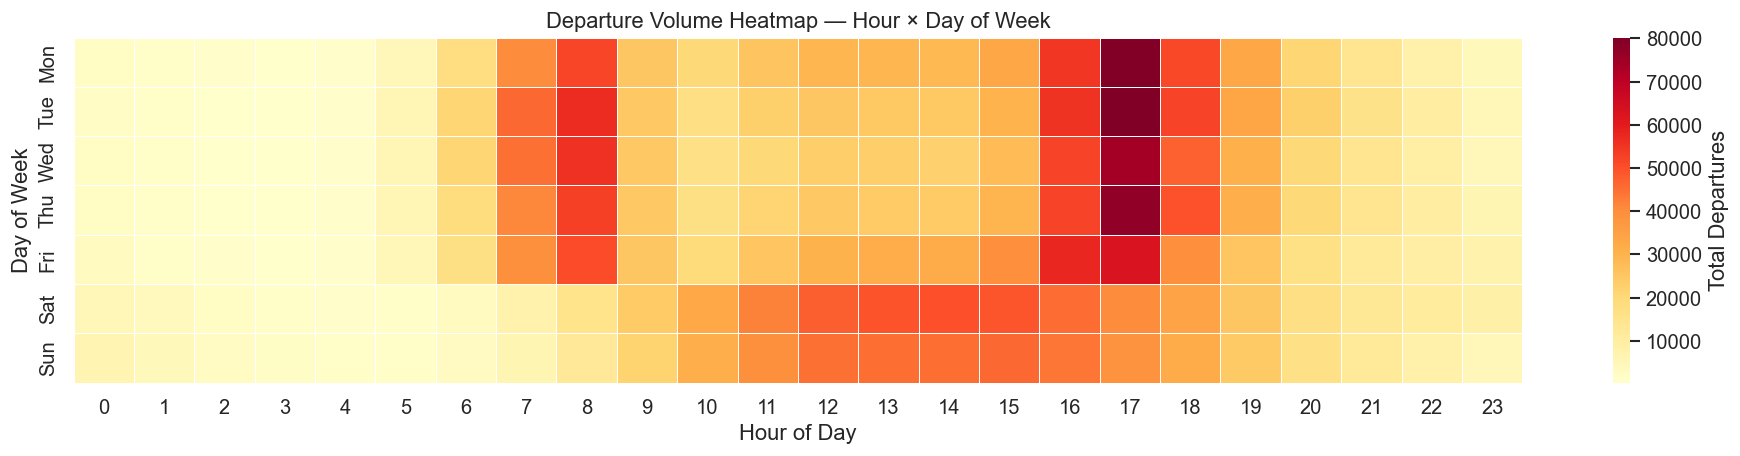

In [7]:
# Heatmap: hour of day × day of week (total departures)
pivot = demand.groupby(["day_of_week", "hour_of_day"])["departures"].sum().unstack("hour_of_day")
pivot.index = DOW_LABELS

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.3, linecolor="white",
            cbar_kws={"label": "Total Departures"}, ax=ax)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day of Week")
ax.set_title("Departure Volume Heatmap — Hour × Day of Week")
plt.tight_layout()
plt.show()

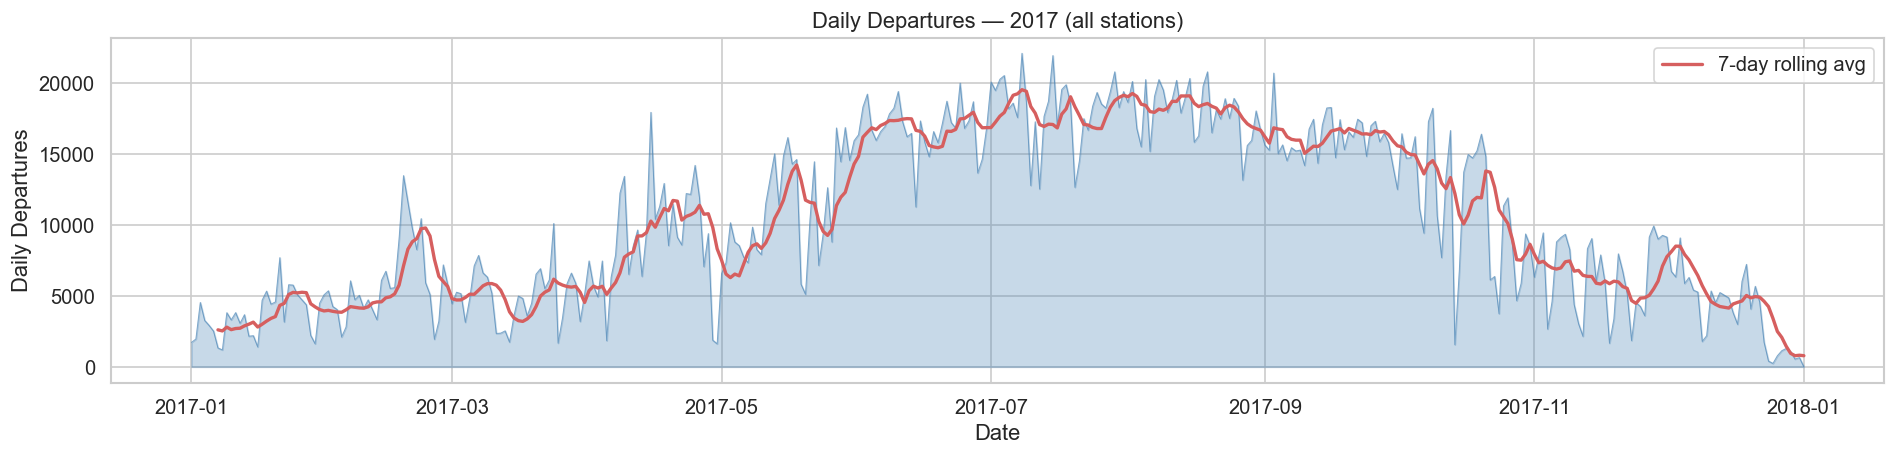

In [8]:
# Daily time series — total departures across all stations
daily = demand.groupby("date")["departures"].sum().reset_index()
daily["date"] = pd.to_datetime(daily["date"])
rolling = daily.set_index("date")["departures"].rolling(7).mean()

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(daily["date"], daily["departures"], alpha=0.3, color="steelblue")
ax.plot(daily["date"], daily["departures"], color="steelblue", linewidth=0.6, alpha=0.6)
ax.plot(rolling.index, rolling.values, color="#D65F5F", linewidth=2, label="7-day rolling avg")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Departures")
ax.set_title("Daily Departures — 2017 (all stations)")
ax.legend()
plt.tight_layout()
plt.show()

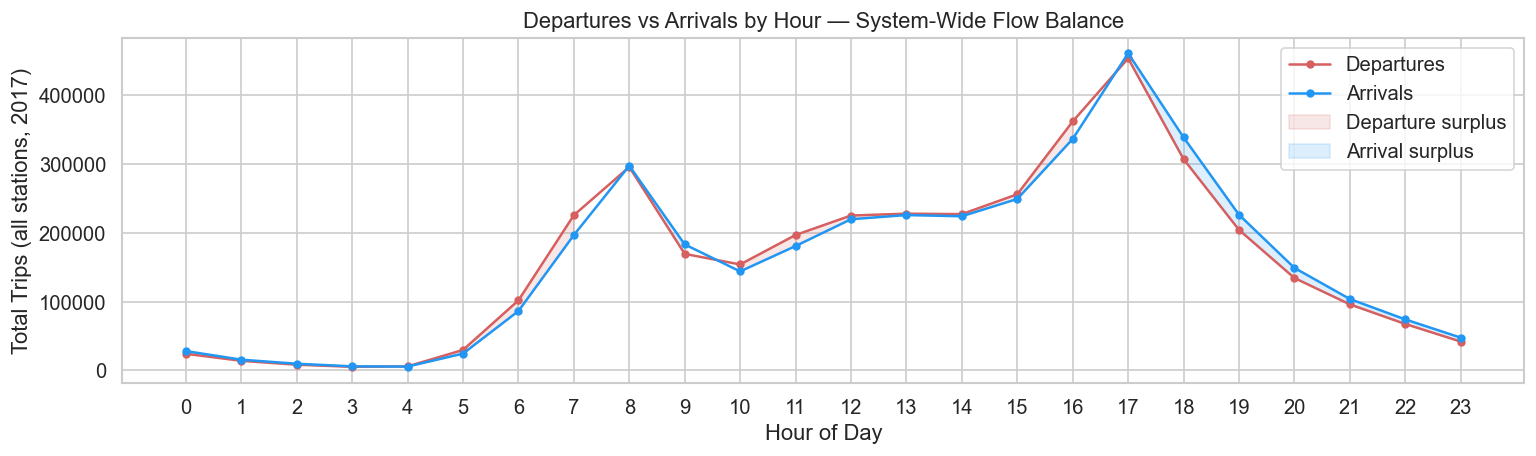

In [9]:
# Arrivals vs departures by hour — flow balance across the day
flow = demand.groupby("hour_of_day")[["departures", "arrivals"]].sum()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(flow.index, flow["departures"], marker="o", markersize=4, label="Departures", color="#D65F5F")
ax.plot(flow.index, flow["arrivals"],   marker="o", markersize=4, label="Arrivals",   color="#2196F3")
ax.fill_between(flow.index, flow["departures"], flow["arrivals"],
                where=flow["departures"] > flow["arrivals"], alpha=0.15, color="#D65F5F", label="Departure surplus")
ax.fill_between(flow.index, flow["departures"], flow["arrivals"],
                where=flow["arrivals"] > flow["departures"], alpha=0.15, color="#2196F3", label="Arrival surplus")
ax.set_xticks(range(0, 24))
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Total Trips (all stations, 2017)")
ax.set_title("Departures vs Arrivals by Hour — System-Wide Flow Balance")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Station-Level Analysis

In [10]:
# Aggregate demand per station
station_agg = (
    demand.groupby("station_id")
    .agg(
        departures  = ("departures",  "sum"),
        arrivals    = ("arrivals",    "sum"),
        net_demand  = ("net_demand",  "sum"),
        latitude    = ("latitude",   "first"),
        longitude   = ("longitude",  "first"),
        name        = ("name",        "first"),
        dpcapacity  = ("dpcapacity",  "first"),
    )
    .reset_index()
)
station_agg["total_trips"] = station_agg["departures"] + station_agg["arrivals"]
print(f"Stations with activity: {len(station_agg)}")

Stations with activity: 585


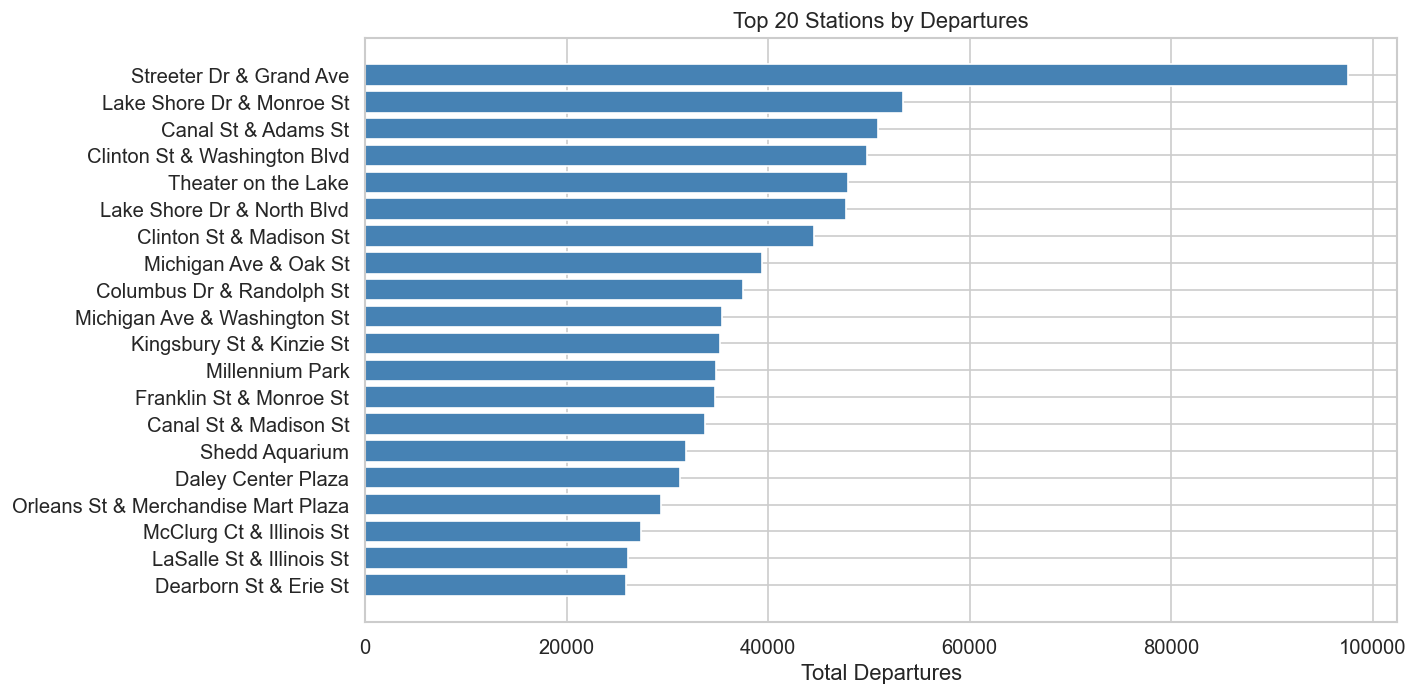

In [11]:
# Top 20 stations by departures
top_dep = station_agg.nlargest(20, "departures")
label_dep = top_dep["name"].fillna(top_dep["station_id"].astype(str))

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(label_dep[::-1], top_dep["departures"][::-1], color="steelblue", edgecolor="white")
ax.set_xlabel("Total Departures")
ax.set_title("Top 20 Stations by Departures")
plt.tight_layout()
plt.show()

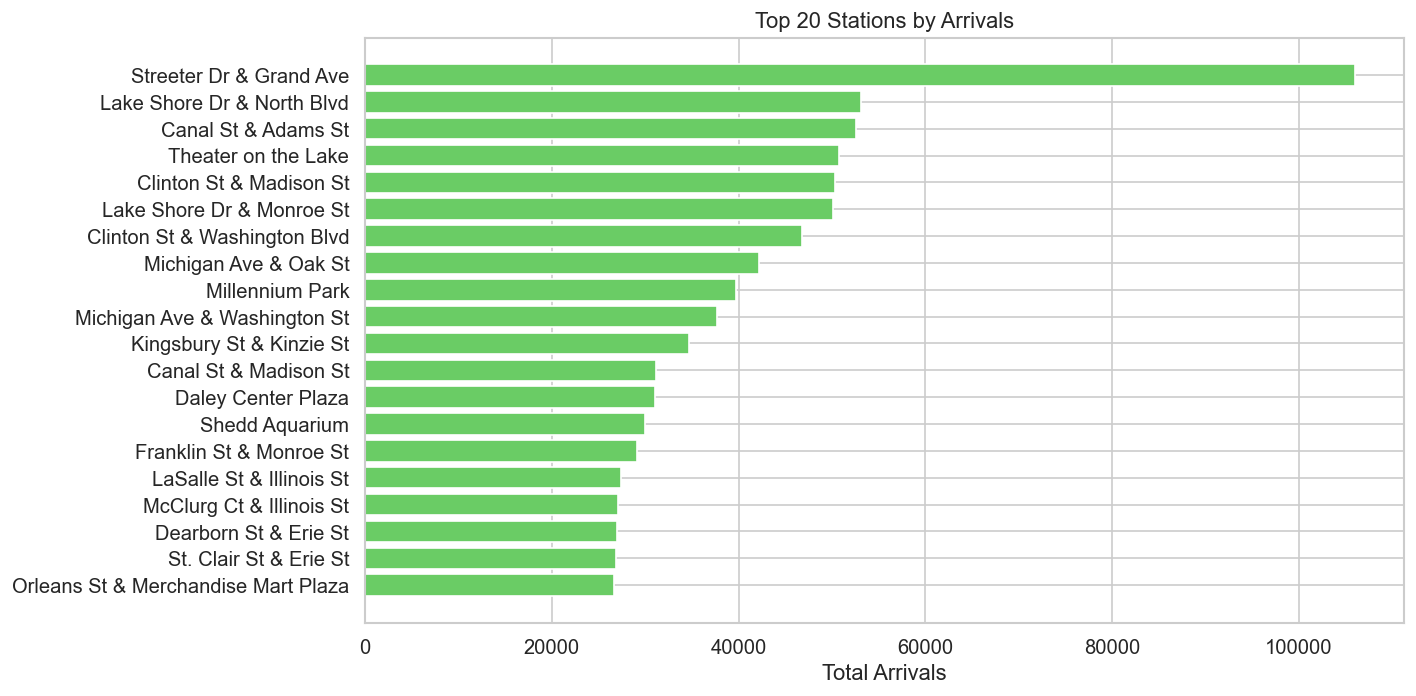

In [12]:
# Top 20 stations by arrivals
top_arr = station_agg.nlargest(20, "arrivals")
label_arr = top_arr["name"].fillna(top_arr["station_id"].astype(str))

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(label_arr[::-1], top_arr["arrivals"][::-1], color="#6ACC65", edgecolor="white")
ax.set_xlabel("Total Arrivals")
ax.set_title("Top 20 Stations by Arrivals")
plt.tight_layout()
plt.show()

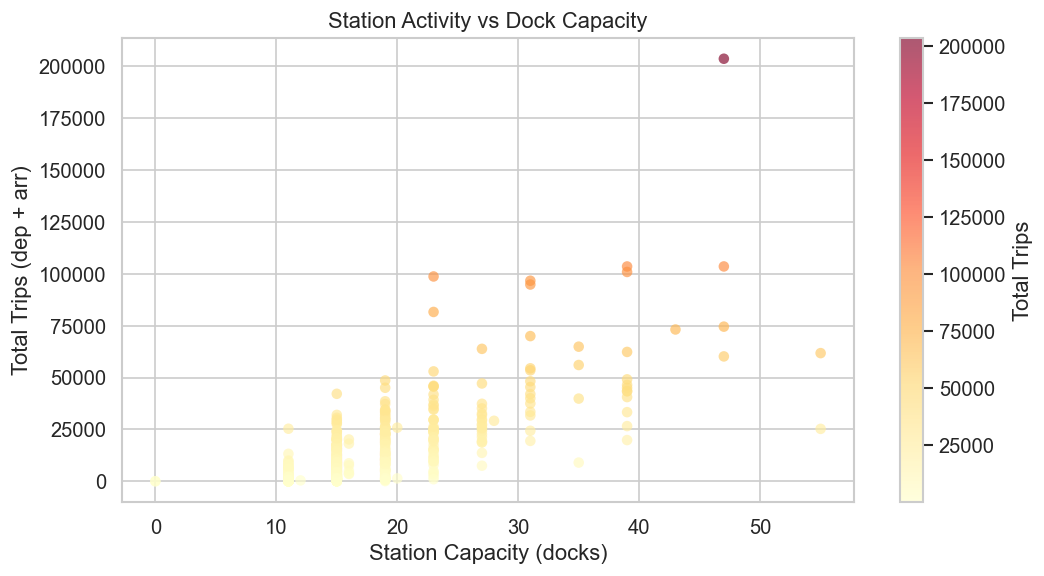

In [13]:
# Station activity vs dock capacity
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(
    station_agg["dpcapacity"], station_agg["total_trips"],
    alpha=0.65, s=40,
    c=station_agg["total_trips"], cmap="YlOrRd", edgecolors="none",
)
plt.colorbar(sc, ax=ax, label="Total Trips")
ax.set_xlabel("Station Capacity (docks)")
ax.set_ylabel("Total Trips (dep + arr)")
ax.set_title("Station Activity vs Dock Capacity")
plt.tight_layout()
plt.show()

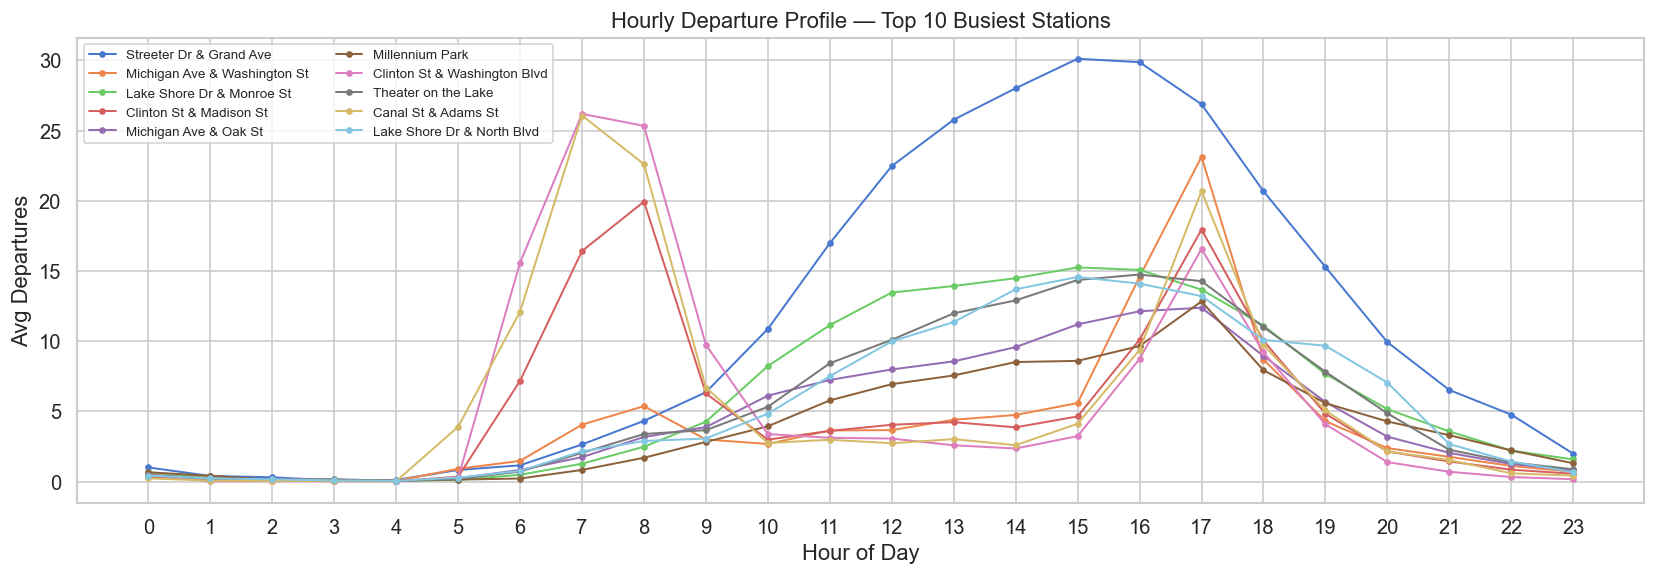

In [14]:
# Average hourly demand profile for top-10 busiest stations
top10_ids = station_agg.nlargest(10, "total_trips")["station_id"].tolist()
top10_demand = demand[demand["station_id"].isin(top10_ids)]
top10_profile = top10_demand.groupby(["station_id", "hour_of_day"])["departures"].mean().reset_index()
top10_profile = top10_profile.merge(station_agg[["station_id", "name"]], on="station_id")

fig, ax = plt.subplots(figsize=(14, 5))
for sid, grp in top10_profile.groupby("station_id"):
    label = grp["name"].iloc[0] or str(sid)
    ax.plot(grp["hour_of_day"], grp["departures"], marker="o", markersize=3, linewidth=1.2, label=label)
ax.set_xticks(range(0, 24))
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Avg Departures")
ax.set_title("Hourly Departure Profile — Top 10 Busiest Stations")
ax.legend(fontsize=8, ncol=2, loc="upper left")
plt.tight_layout()
plt.show()

## 5. Chicago Maps

In [15]:
map_data = station_agg.dropna(subset=["latitude", "longitude"])

In [16]:
# --- Map 1: Station total activity (circle size = trip volume) ---
m1 = folium.Map(location=CHICAGO, zoom_start=12, tiles="CartoDB positron")

max_trips = map_data["total_trips"].max()
for _, row in map_data.iterrows():
    radius = 3 + 18 * (row["total_trips"] / max_trips)
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=radius,
        color="none", fill=True, fill_color="#D65F5F", fill_opacity=0.65,
        tooltip=(
            f"{row['name']} | "
            f"dep: {int(row['departures']):,} | "
            f"arr: {int(row['arrivals']):,} | "
            f"capacity: {int(row['dpcapacity']) if pd.notna(row['dpcapacity']) else 'N/A'}"
        ),
    ).add_to(m1)

m1.save(str(FIGURES / "map_station_activity.html"))
print("Saved: map_station_activity.html")
m1

Saved: map_station_activity.html


In [17]:
# --- Map 2: Departure density heatmap ---
m2 = folium.Map(location=CHICAGO, zoom_start=12, tiles="CartoDB dark_matter")

heat_dep = map_data[["latitude", "longitude", "departures"]].dropna()
fplugins.HeatMap(
    heat_dep.values.tolist(),
    min_opacity=0.3, max_zoom=14, radius=18, blur=12,
    gradient={0.3: "blue", 0.6: "lime", 0.8: "yellow", 1.0: "red"},
).add_to(m2)

m2.save(str(FIGURES / "map_departure_heatmap.html"))
print("Saved: map_departure_heatmap.html")
m2

Saved: map_departure_heatmap.html


In [18]:
# --- Map 3: Net demand imbalance (blue = annual surplus, red = annual deficit) ---
m3 = folium.Map(location=CHICAGO, zoom_start=12, tiles="CartoDB positron")

p95 = map_data["net_demand"].abs().quantile(0.95)
for _, row in map_data.iterrows():
    net = row["net_demand"]
    color  = "#2196F3" if net >= 0 else "#F44336"
    radius = 3 + 14 * min(abs(net) / p95, 1)
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=radius,
        color="none", fill=True, fill_color=color, fill_opacity=0.7,
        tooltip=f"{row['name']} | net demand: {int(net):+,}",
    ).add_to(m3)

m3.save(str(FIGURES / "map_net_demand_imbalance.html"))
print("Saved: map_net_demand_imbalance.html")
print("Blue = bike surplus (arrivals > departures) | Red = bike deficit (departures > arrivals)")
m3

Saved: map_net_demand_imbalance.html
Blue = bike surplus (arrivals > departures) | Red = bike deficit (departures > arrivals)


In [19]:
# --- Map 4: Animated heatmap — avg weekday departure by hour of day ---
weekday = demand[demand["day_of_week"] < 5]
hourly_avg = (
    weekday.groupby(["station_id", "hour_of_day"])
    .agg(departures=("departures", "mean"), latitude=("latitude", "first"), longitude=("longitude", "first"))
    .reset_index()
    .dropna(subset=["latitude", "longitude"])
)

heat_frames = [
    hourly_avg[hourly_avg["hour_of_day"] == h][["latitude", "longitude", "departures"]].values.tolist()
    for h in range(24)
]

m4 = folium.Map(location=CHICAGO, zoom_start=12, tiles="CartoDB dark_matter")
fplugins.HeatMapWithTime(
    heat_frames,
    index=[f"{h:02d}:00" for h in range(24)],
    auto_play=True, max_opacity=0.85, radius=18,
    gradient={0.3: "blue", 0.6: "cyan", 0.8: "yellow", 1.0: "red"},
).add_to(m4)

m4.save(str(FIGURES / "map_animated_departures.html"))
print("Saved: map_animated_departures.html  (avg weekday departure intensity by hour)")
m4

Saved: map_animated_departures.html  (avg weekday departure intensity by hour)


## 6. Weather Impact

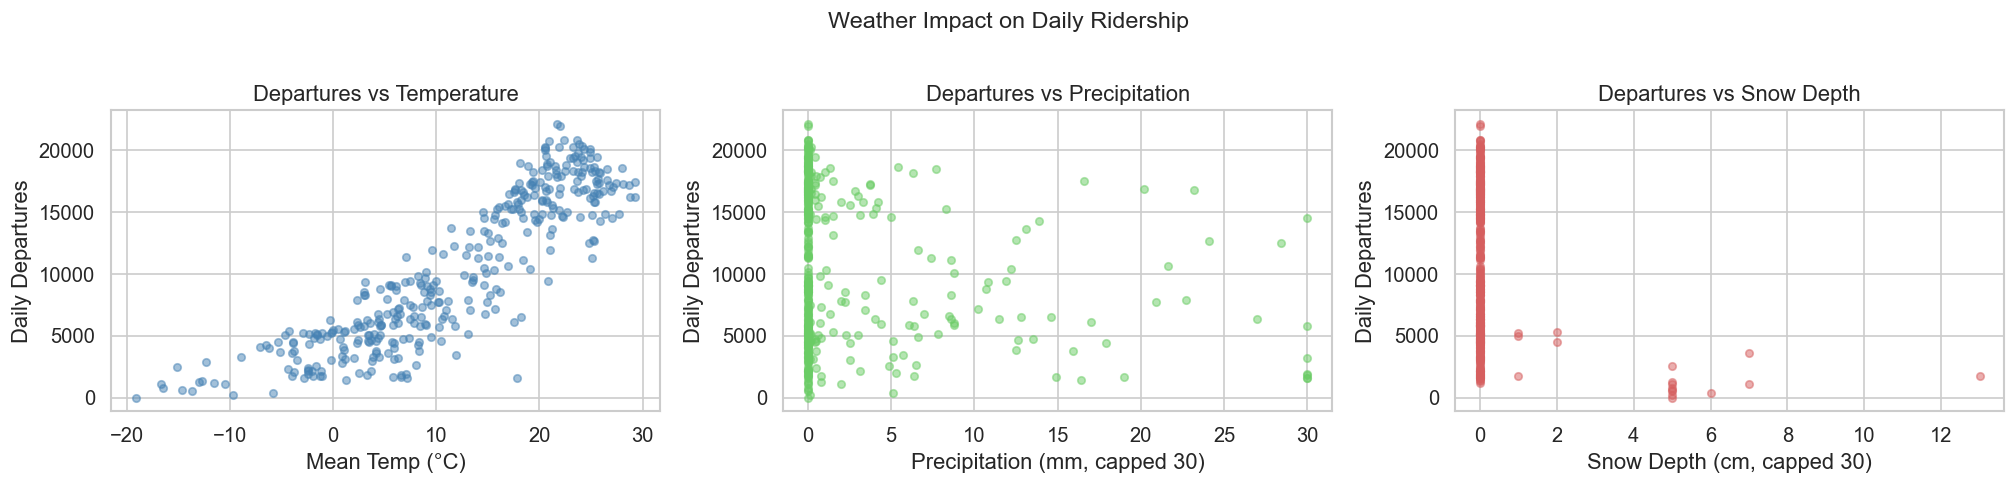

In [20]:
# Daily totals — one weather value per day is enough (take first since it's daily)
daily_weather = (
    demand.groupby("date")
    .agg(
        total_departures = ("departures", "sum"),
        temp  = ("temp",  "first"),
        prcp  = ("prcp",  "first"),
        snwd  = ("snwd",  "first"),
        wspd  = ("wspd",  "first"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].scatter(daily_weather["temp"], daily_weather["total_departures"],
                alpha=0.5, s=20, color="steelblue")
axes[0].set_xlabel("Mean Temp (°C)")
axes[0].set_ylabel("Daily Departures")
axes[0].set_title("Departures vs Temperature")

axes[1].scatter(daily_weather["prcp"].clip(upper=30), daily_weather["total_departures"],
                alpha=0.5, s=20, color="#6ACC65")
axes[1].set_xlabel("Precipitation (mm, capped 30)")
axes[1].set_ylabel("Daily Departures")
axes[1].set_title("Departures vs Precipitation")

axes[2].scatter(daily_weather["snwd"].clip(upper=30), daily_weather["total_departures"],
                alpha=0.5, s=20, color="#D65F5F")
axes[2].set_xlabel("Snow Depth (cm, capped 30)")
axes[2].set_ylabel("Daily Departures")
axes[2].set_title("Departures vs Snow Depth")

plt.suptitle("Weather Impact on Daily Ridership", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

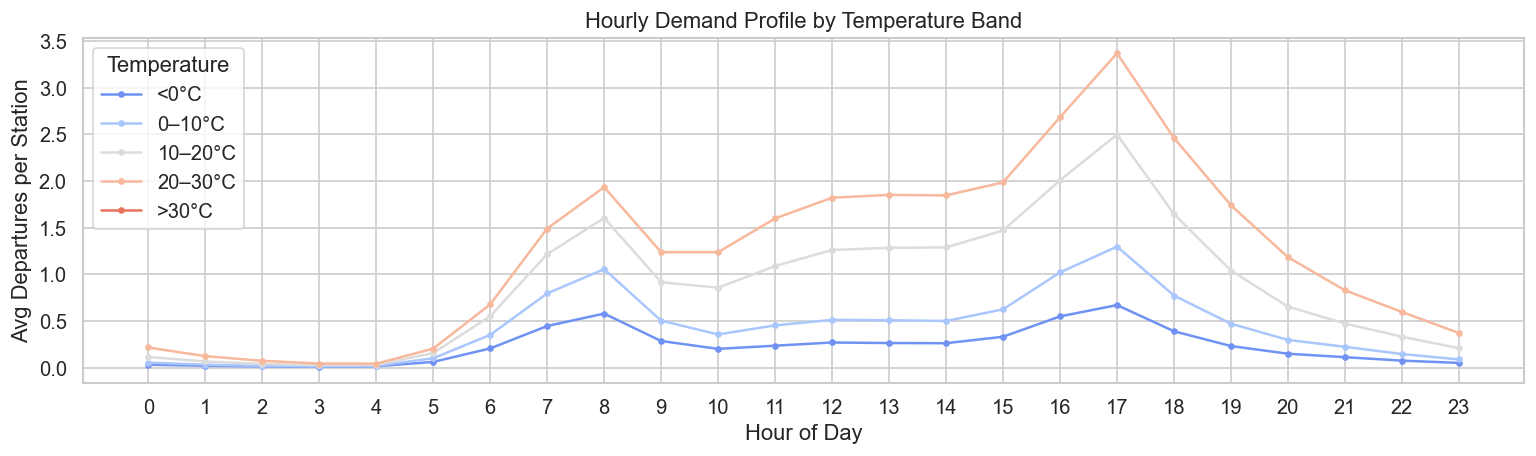

In [21]:
# Hourly demand profile split by temperature band
demand["temp_bin"] = pd.cut(
    demand["temp"],
    bins=[-20, 0, 10, 20, 30, 40],
    labels=["<0°C", "0–10°C", "10–20°C", "20–30°C", ">30°C"],
)
temp_profile = demand.groupby(["temp_bin", "hour_of_day"])["departures"].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 4))
palette = sns.color_palette("coolwarm", 5)
for i, (tbin, grp) in enumerate(temp_profile.groupby("temp_bin")):
    ax.plot(grp["hour_of_day"], grp["departures"], marker="o", markersize=3, label=str(tbin), color=palette[i])
ax.set_xticks(range(0, 24))
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Avg Departures per Station")
ax.set_title("Hourly Demand Profile by Temperature Band")
ax.legend(title="Temperature", loc="upper left")
plt.tight_layout()
plt.show()

## 7. Demand Imbalance

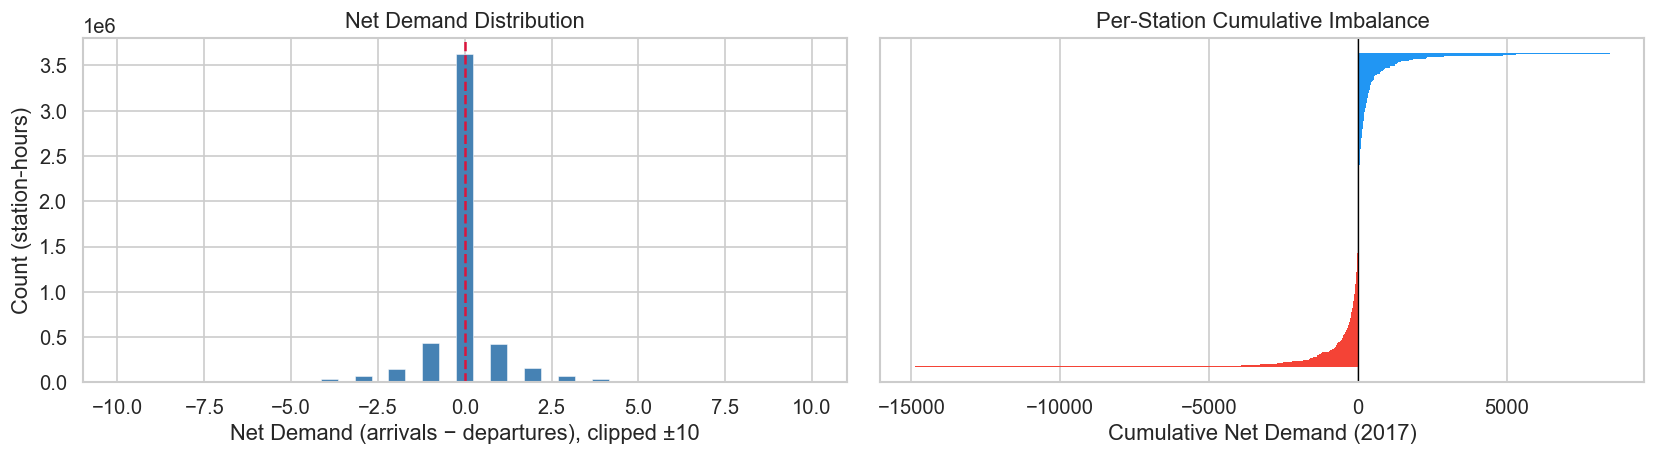

Stations with net surplus : 300
Stations with net deficit : 277


In [22]:
# Net demand distribution across all station-hours
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(demand["net_demand"].clip(-10, 10), bins=41,
             color="steelblue", edgecolor="white", linewidth=0.3)
axes[0].axvline(0, color="crimson", linestyle="--")
axes[0].set_xlabel("Net Demand (arrivals − departures), clipped ±10")
axes[0].set_ylabel("Count (station-hours)")
axes[0].set_title("Net Demand Distribution")

# Sorted cumulative net demand per station
sn_sorted = station_agg.sort_values("net_demand")
axes[1].barh(
    range(len(sn_sorted)),
    sn_sorted["net_demand"],
    color=["#2196F3" if v >= 0 else "#F44336" for v in sn_sorted["net_demand"]],
    height=1.0, edgecolor="none",
)
axes[1].set_yticks([])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Cumulative Net Demand (2017)")
axes[1].set_title("Per-Station Cumulative Imbalance")

plt.tight_layout()
plt.show()

print(f"Stations with net surplus : {(station_agg['net_demand'] > 0).sum()}")
print(f"Stations with net deficit : {(station_agg['net_demand'] < 0).sum()}")

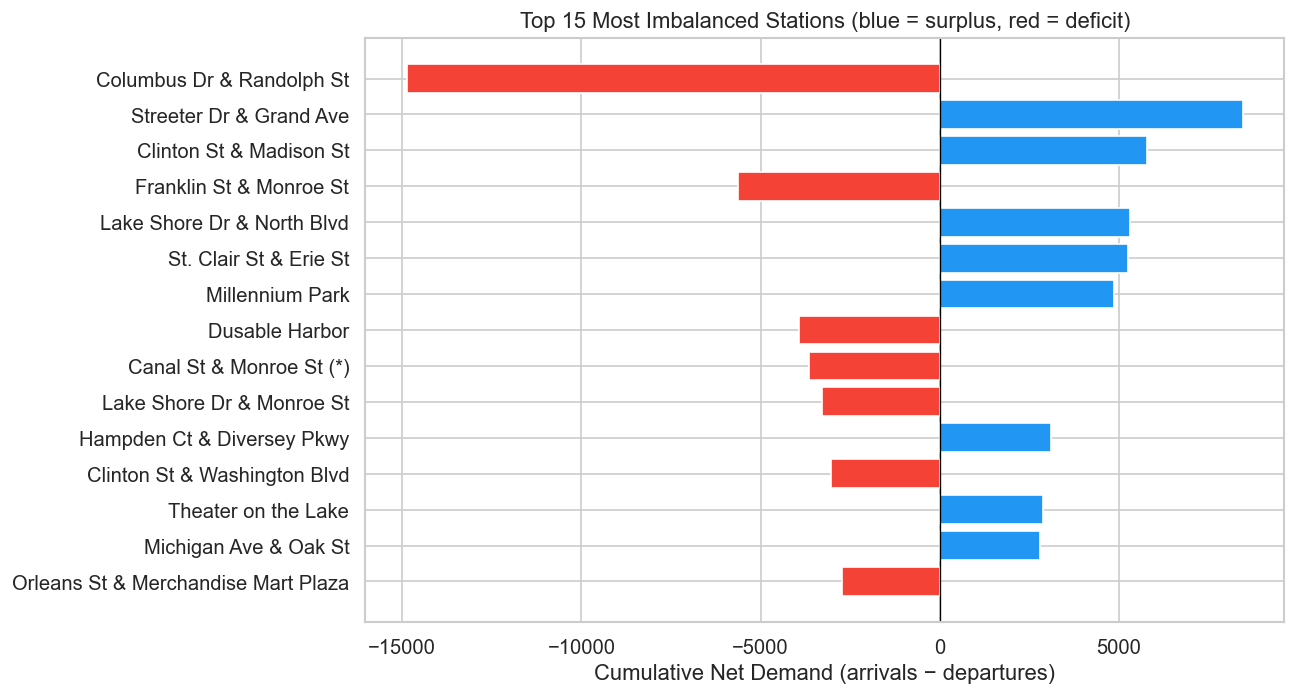

In [23]:
# Top 15 most imbalanced stations
top_imb = station_agg.assign(abs_net=station_agg["net_demand"].abs()).nlargest(15, "abs_net")
label_imb = top_imb["name"].fillna(top_imb["station_id"].astype(str))
colors_imb = ["#2196F3" if v >= 0 else "#F44336" for v in top_imb["net_demand"]]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(label_imb[::-1], top_imb["net_demand"][::-1], color=colors_imb[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Cumulative Net Demand (arrivals − departures)")
ax.set_title("Top 15 Most Imbalanced Stations (blue = surplus, red = deficit)")
plt.tight_layout()
plt.show()

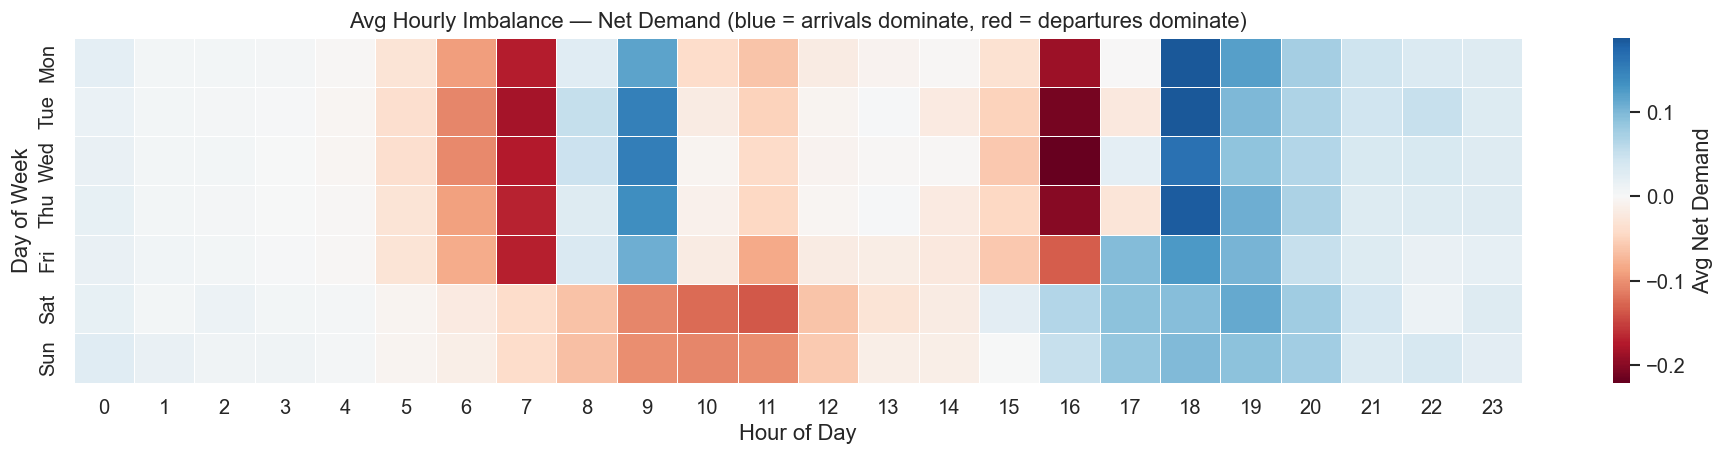

In [24]:
# Imbalance heatmap: avg net demand per hour × day of week
imb_pivot = demand.groupby(["day_of_week", "hour_of_day"])["net_demand"].mean().unstack("hour_of_day")
imb_pivot.index = DOW_LABELS

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    imb_pivot, cmap="RdBu", center=0,
    linewidths=0.3, linecolor="white",
    cbar_kws={"label": "Avg Net Demand"},
    ax=ax,
)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day of Week")
ax.set_title("Avg Hourly Imbalance — Net Demand (blue = arrivals dominate, red = departures dominate)")
plt.tight_layout()
plt.show()